In [1]:
import numpy as np
import pandas as pd

In [2]:
true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")

In [3]:
true_df["label"] = 1
fake_df["label"] = 0

In [4]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [5]:
df = pd.concat([true_df, fake_df])

In [6]:
# shuffle data
df = df.sample(frac=1).reset_index(drop=True)

In [7]:
df.shape
df.head()

,title,text,subject,date,label
0,PAUL JOSEPH WATSON Exposes Media’s Obsession W...,Here was Trump s epic response to the leftist ...,left-news,"Dec 3, 2016",0
1,WHOA! WATCH Former Teen Hollywood Actor: “I Ca...,Are we finally watching the end times for Holl...,politics,"Oct 10, 2017",0
2,Senator asks ethics office to review Trump hot...,WASHINGTON (Reuters) - The top Democrat on the...,politicsNews,"May 22, 2017",1
3,UK PM May says Donald Trump was wrong to retwe...,AMMAN (Reuters) - British Prime Minister There...,politicsNews,"November 30, 2017",1
4,Ukraine shelves controversial corruption law a...,KIEV (Reuters) - Ukrainian lawmakers on Thursd...,worldnews,"December 7, 2017",1


In [8]:
df["content"] = df["title"] + " " + df["text"]

X = df["content"]
y = df["label"]

In [9]:
X.head()

0    PAUL JOSEPH WATSON Exposes Media’s Obsession W...
1    WHOA! WATCH Former Teen Hollywood Actor: “I Ca...
2    Senator asks ethics office to review Trump hot...
3    UK PM May says Donald Trump was wrong to retwe...
4    Ukraine shelves controversial corruption law a...
Name: content, dtype: str

# pre-processing

### 1.covert to lower case

In [10]:
X = X.str.lower()

### 2.Removing URL

In [11]:
import re
def remove_url(text):
    text = re.sub(r"http\S+", "", text)

    return text

X = X.apply(remove_url)

### 3. Removing html 

In [12]:
def remove_html(text):
    text = re.sub(r"<.*?>", "", text)
    return text

X = X.apply(remove_html)

### 4.Removing punctuation

In [13]:
def remove_punctuation(text):
    text = re.sub(r"[^A-Za-z0-9\s]", "", text)
    return text

X = X.apply(remove_punctuation)

### 5.Removing stopwords

In [14]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DFIT\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DFIT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DFIT\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\DFIT\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [15]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [16]:
def remove_stopwords(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))

    filtered_words = []

    for word in tokens:
        if word not in stop_words:
            filtered_words.append(word)

    return " ".join(filtered_words)

X = X.apply(remove_stopwords)

In [17]:
X.head()

0    paul joseph watson exposes medias obsession tr...
1    whoa watch former teen hollywood actor tell 1 ...
2    senator asks ethics office review trump hotel ...
3    uk pm may says donald trump wrong retweet farr...
4    ukraine shelves controversial corruption law d...
Name: content, dtype: str

### lemmatization

In [18]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

In [19]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


def lemmatize_text(text):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)

    lemmas = []

    for word, tag in tags:
        pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos)
        lemmas.append(lemma)

    return " ".join(lemmas)

X = X.apply(lemmatize_text)   

In [20]:
X.head()

0    christian mom think good idea put hateful rap ...
1    plan parenthood shooter speak sound like gop c...
2    gop rep defense jeff session straight kkk audi...
3    watch trump lash grill break point abc host ge...
4    liz warren call crazy claim steve bannon white...
Name: content, dtype: str

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Vectorization

In [22]:
from sklearn.feature_extraction.text import  TfidfVectorizer

tf =  TfidfVectorizer(max_features = 10000)

X_train_tf = tf.fit_transform(X_train)
X_test_tf = tf.transform(X_test)

# Dataset & Dataloader

In [23]:
X_train.shape

(35918,)

In [25]:
X_test.shape

(8980,)

# Model Train

## 1.LogisticRegression

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix,recall_score

model = LogisticRegression()

model.fit(X_train_tf, y_train)

y_pred = model.predict(X_test_tf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9855233853006682
Precision: 0.9819376026272578
F1 Score: 0.9847094801223242
Recall Score: 0.9874970511913187
Confusion Matrix:
 [[4664   77]
 [  53 4186]]


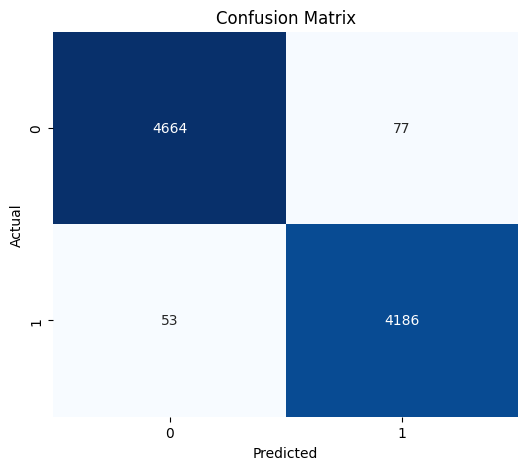

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 2.Naive Bayes

In [28]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tf, y_train)

y_pred = model.predict(X_test_tf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9316258351893095
Precision: 0.9351740696278511
F1 Score: 0.9269395525940028
Recall Score: 0.9188487850908234
Confusion Matrix:
 [[4471  270]
 [ 344 3895]]


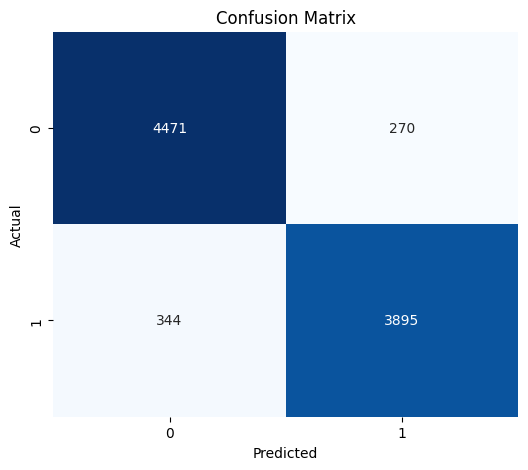

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 3.SVM

In [40]:
from sklearn.svm import LinearSVC

model = LinearSVC(C=1.0, max_iter=5000)
model.fit(X_train_tf, y_train)

y_pred = model.predict(X_test_tf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9944320712694877
Precision: 0.9922444183313749
F1 Score: 0.9941134918766188
Recall Score: 0.9959896201934418
Confusion Matrix:
 [[4708   33]
 [  17 4222]]


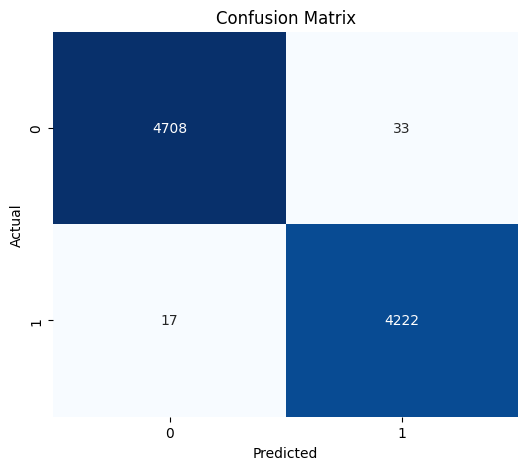

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Random Forest

In [32]:
from sklearn.tree import DecisionTreeClassifier

In [38]:
model =  DecisionTreeClassifier(max_depth=4)

model.fit(X_train_tf, y_train)

y_pred = model.predict(X_test_tf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9951002227171493
Precision: 0.9922553391222718
F1 Score: 0.9948235294117647
Recall Score: 0.9974050483604624
Confusion Matrix:
 [[4708   33]
 [  11 4228]]


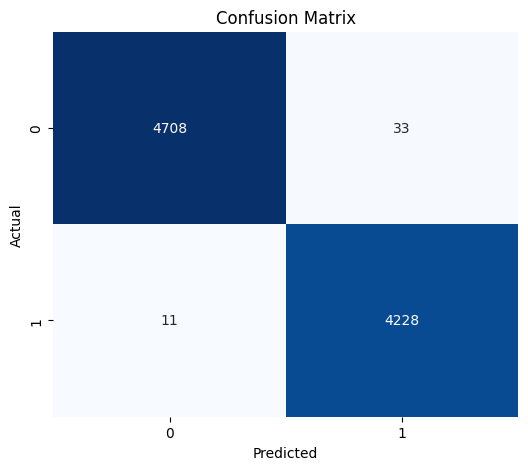

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
# Linear SVC Model save
import pickle

pickle.dump(tf, open("tfidf.pkl", "wb"))
pickle.dump(model, open("model.pkl", "wb"))